In [2]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import yfinance as yf
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [3]:
spy_prices = pd.read_csv('SPY_2018.csv')
spy_prices.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018/1/2,267.839996,268.809998,267.399994,268.769989,258.858276,86655700
1,2018/1/3,268.959991,270.640015,268.959991,270.470001,260.495544,90070400
2,2018/1/4,271.200012,272.160004,270.540009,271.609985,261.593475,80636400


In [4]:
class DeepEvolutionStrategy:

    inputs = None

    def __init__(
        self, weights, reward_function, population_size, sigma, learning_rate
    ):
        self.weights = weights
        self.reward_function = reward_function
        self.population_size = population_size
        self.sigma = sigma
        self.learning_rate = learning_rate

    def _get_weight_from_population(self, weights, population):
        weights_population = []
        for index, i in enumerate(population):
            jittered = self.sigma * i
            weights_population.append(weights[index] + jittered)
        return weights_population

    def getWeights(self):
        return self.weights

    def train(self, epoch = 100, print_every = 1):
        lasttime = time.time()
        for i in range(epoch):
            population = []
            rewards = np.zeros(self.population_size)
            for k in range(self.population_size):
                x = []
                for w in self.weights:
                    x.append(np.random.randn(*w.shape))
                population.append(x)
            for k in range(self.population_size):
                weights_population = self._get_weight_from_population(
                    self.weights, population[k]
                )
                rewards[k] = self.reward_function(weights_population)
            rewards = (rewards - np.mean(rewards)) / (np.std(rewards) + 1e-7)
            for index, w in enumerate(self.weights):
                A = np.array([p[index] for p in population])
                self.weights[index] = (
                    w
                    + self.learning_rate
                    / (self.population_size * self.sigma)
                    * np.dot(A.T, rewards).T
                )
            if (i + 1) % print_every == 0:
                print(
                    f'訓練週期 {i + 1}. 最終獎勵：{self.reward_function(self.weights)}'
                )
        print('=====================================')
        print(f'訓練時間：{time.time() - lasttime} 秒')

In [5]:
class Model:
    def __init__(self, input_size, layer_size, output_size):
        self.weights = [
            np.random.randn(input_size, layer_size),
            np.random.randn(layer_size, output_size),
            np.random.randn(1, layer_size),
        ]

    def predict(self, inputs):
        feed = np.dot(inputs, self.weights[0]) + self.weights[-1]
        decision = np.dot(feed, self.weights[1])
        return decision

    def getWeights(self):
        return self.weights

    def set_weights(self, weights):
        self.weights = weights

In [6]:
class Agent:

    POPULATION_SIZE = 15
    SIGMA = 0.1
    LEARNING_RATE = 0.03

    def __init__(self, model, window_size, trend, skip, initial_money):
        self.model = model
        self.window_size = window_size
        self.half_window = window_size // 2
        self.trend = trend
        self.skip = skip
        self.initial_money = initial_money
        self.es = DeepEvolutionStrategy(
            self.model.getWeights(),
            self.getReward,
            self.POPULATION_SIZE,
            self.SIGMA,
            self.LEARNING_RATE,
        )

    def act(self, sequence):
        decision = self.model.predict(np.array(sequence))
        return np.argmax(decision[0])
    
    def getState(self, t):
        window_size = self.window_size + 1
        d = t - window_size + 1
        block = self.trend[d : t + 1] if d >= 0 else -d * [self.trend[0]] + self.trend[0 : t + 1]
        res = []
        for i in range(window_size - 1):
            res.append(block[i + 1] - block[i])
        return np.array([res])

    def getReward(self, weights):
        initial_money = self.initial_money
        starting_money = initial_money
        self.model.weights = weights
        state = self.getState(0)
        inventory = []
        quantity = 0
        for t in range(0, len(self.trend) - 1, self.skip):
            action = self.act(state)
            next_state = self.getState(t + 1)
            
            if action == 1 and starting_money >= self.trend[t]:
                inventory.append(self.trend[t])
                starting_money -= close[t]
                
            elif action == 2 and len(inventory):
                bought_price = inventory.pop(0)
                starting_money += self.trend[t]

            state = next_state
        return ((starting_money - initial_money) / initial_money) * 100

    def fit(self, iterations, checkpoint):
        self.es.train(iterations, print_every = checkpoint)

    def buy(self):
        initial_money = self.initial_money
        state = self.getState(0)
        starting_money = initial_money
        states_sell = []
        states_buy = []
        inventory = []
        for t in range(0, len(self.trend) - 1, self.skip):
            action = self.act(state)
            next_state = self.getState(t + 1)
            
            if action == 1 and initial_money >= self.trend[t]:
                inventory.append(self.trend[t])
                initial_money -= self.trend[t]
                states_buy.append(t)
                print('第 %s 日 > 購買 1 股 價格 %s，總資產 %s' % (
                    str(t).rjust(3),
                    str("%.5f" % self.trend[t]).rjust(10),
                    str("%.3f" % initial_money).rjust(10)
                ))
            
            elif action == 2 and len(inventory):
                bought_price = inventory.pop(0)
                initial_money += self.trend[t]
                states_sell.append(t)
                try:
                    invest = ((close[t] - bought_price) / bought_price) * 100
                except:
                    invest = 0
                print('第 %s 日 > 賣出 1 股 價格 %s，總資產 %s > 獲利 %s %%' % (
                    str(t).rjust(3),
                    str("%.5f" % close[t]).rjust(10),
                    str("%.3f" % initial_money).rjust(10),
                    str("%.2f" % invest).rjust(5)
                ))
            state = next_state

        invest = ((initial_money - starting_money) / starting_money) * 100
        total_gains = initial_money - starting_money
        return states_buy, states_sell, total_gains, invest

In [7]:
close = spy_prices.Close.values.tolist()
window_size = 30
skip = 1
initial_money = 10000

model = Model(input_size = window_size, layer_size = 500, output_size = 3)
agent = Agent(model = model, 
              window_size = window_size,
              trend = close,
              skip = skip,
              initial_money = initial_money)
agent.fit(iterations = 500, checkpoint = 100)

訓練週期 100. 最終獎勵：16.39059873999993
訓練週期 200. 最終獎勵：26.263598439999967
訓練週期 300. 最終獎勵：30.565300399999963
訓練週期 400. 最終獎勵：27.65939923
訓練週期 500. 最終獎勵：32.95999799999998
訓練時間：24.078912019729614 秒


In [8]:
states_buy, states_sell, total_gains, invest = agent.buy()

第   0 日 > 購買 1 股 價格  268.76999，總資產   9731.230
第   1 日 > 賣出 1 股 價格  270.47000，總資產  10001.700 > 獲利  0.63 %
第  22 日 > 購買 1 股 價格  275.45001，總資產   9726.250
第  23 日 > 購買 1 股 價格  263.92999，總資產   9462.320
第  26 日 > 購買 1 股 價格  257.63000，總資產   9204.690
第  27 日 > 購買 1 股 價格  261.50000，總資產   8943.190
第  29 日 > 賣出 1 股 價格  266.00000，總資產   9209.190 > 獲利 -3.43 %
第  30 日 > 購買 1 股 價格  269.59000，總資產   8939.600
第  33 日 > 購買 1 股 價格  271.39999，總資產   8668.200
第  34 日 > 購買 1 股 價格  270.04999，總資產   8398.150
第  37 日 > 賣出 1 股 價格  277.89999，總資產   8676.050 > 獲利  5.29 %
第  38 日 > 購買 1 股 價格  274.42999，總資產   8401.620
第  39 日 > 購買 1 股 價格  271.64999，總資產   8129.970
第  40 日 > 購買 1 股 價格  267.70001，總資產   7862.270
第  42 日 > 購買 1 股 價格  272.19000，總資產   7590.080
第  43 日 > 購買 1 股 價格  272.88000，總資產   7317.200
第  46 日 > 賣出 1 股 價格  278.87000，總資產   7596.070 > 獲利  8.24 %
第  47 日 > 購買 1 股 價格  278.51999，總資產   7317.550
第  48 日 > 購買 1 股 價格  276.72000，總資產   7040.830
第  50 日 > 購買 1 股 價格  275.00000，總資產   6765.830
第  51 日 > 購買 1 股 價格  274.200

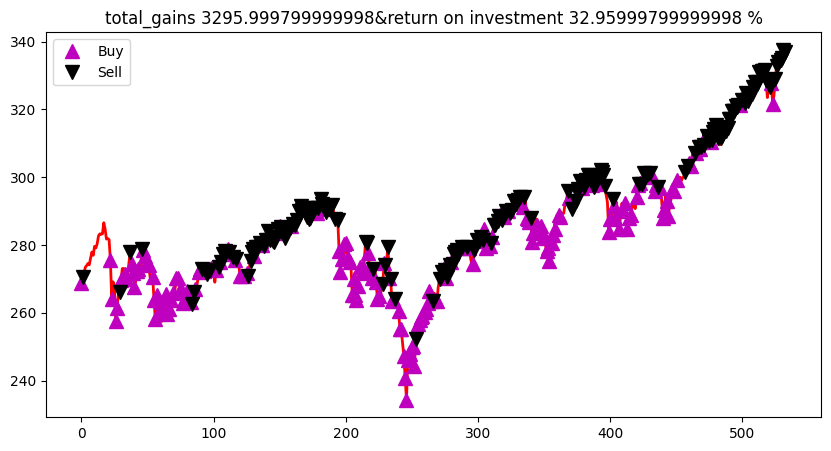

In [9]:
fig = plt.figure(figsize=(10, 5))
plt.plot(close, color='r', lw=2.)
plt.plot(close, '^', markersize=10, color='m', label = 'Buy', markevery = states_buy)
plt.plot(close, 'v', markersize=10, color='k', label = 'Sell', markevery = states_sell)
plt.title(f'total_gains {total_gains}&return on investment {invest} %')
plt.legend()
plt.show()